In [9]:
import pandas as pd
import numpy as np
import sys
from pathlib import Path
from matplotlib import pyplot as plt
import importlib
from pandas.plotting import scatter_matrix
import utils

In [7]:
# load the data
data_path = 'dataset/train.csv'
score_data = pd.read_csv(data_path)
score_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


In [6]:
score_data.head()

,id,age,gender,course,study_hours,class_attendance,internet_access,sleep_hours,sleep_quality,study_method,facility_rating,exam_difficulty,exam_score
0,0,21,female,b.sc,7.91,98.8,no,4.9,average,online videos,low,easy,78.3
1,1,18,other,diploma,4.95,94.8,yes,4.7,poor,self-study,medium,moderate,46.7
2,2,20,female,b.sc,4.68,92.6,yes,5.8,poor,coaching,high,moderate,99.0
3,3,19,male,b.sc,2.00,49.5,yes,8.3,average,group study,high,moderate,63.9
4,4,23,male,bca,7.65,86.9,yes,9.6,good,self-study,high,easy,100.0


## First Glance
- There are 630,000 rows and 13 columns.
- Among the variables, six are numerical and 7 are categorical.
- There are some demographic information such as age, gender, course
- One of them is an identifier (id) -> need to remove this column in when fitting a model
- Exam score is a label -> make sure it is excluded before I process the data
- No missing data
## Next steps
- Summary statistics of numerical columns.
- Check for any categorical abnormality in the categorical columns.

In [7]:
score_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                630000 non-null  int64  
 1   age               630000 non-null  int64  
 2   gender            630000 non-null  str    
 3   course            630000 non-null  str    
 4   study_hours       630000 non-null  float64
 5   class_attendance  630000 non-null  float64
 6   internet_access   630000 non-null  str    
 7   sleep_hours       630000 non-null  float64
 8   sleep_quality     630000 non-null  str    
 9   study_method      630000 non-null  str    
 10  facility_rating   630000 non-null  str    
 11  exam_difficulty   630000 non-null  str    
 12  exam_score        630000 non-null  float64
dtypes: float64(4), int64(2), str(7)
memory usage: 62.5 MB


## Observation
- For most numerical columns, data is not heavily skewed (i.e. means and medians are not very far away)
- Based on mean and standard deviation of 'age', we see that students are mostly college students

In [12]:
# numerical column exploration
score_data.drop(columns=['id']).describe(include='number')

,age,study_hours,class_attendance,sleep_hours,exam_score
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,20.545821,4.002337,71.987261,7.072758,62.506672
std,2.260238,2.359880,17.430098,1.744811,18.916884
min,17.000000,0.080000,40.600000,4.100000,19.599000
25%,19.000000,1.970000,57.000000,5.600000,48.800000
50%,21.000000,4.000000,72.600000,7.100000,62.600000
75%,23.000000,6.050000,87.200000,8.600000,76.300000
max,24.000000,7.910000,99.400000,9.900000,100.000000


## Observation
- Age is of discrete value while others are continuous
- 'age', 'study_hours', 'class_attendance', and 'sleep_hours' are relatively spread out in their ranages, with some variables having spikes at their ends, suggesting the values were capped.
- The distribution for exam score looks like a bell shape with unusual spikes at 20 and 100, suggesting that the data might be capped at 20 and 100
## Next step
- Check if 'class_attendance', 'study_hours', 'sleep_hours', and 'exam_score' were capped

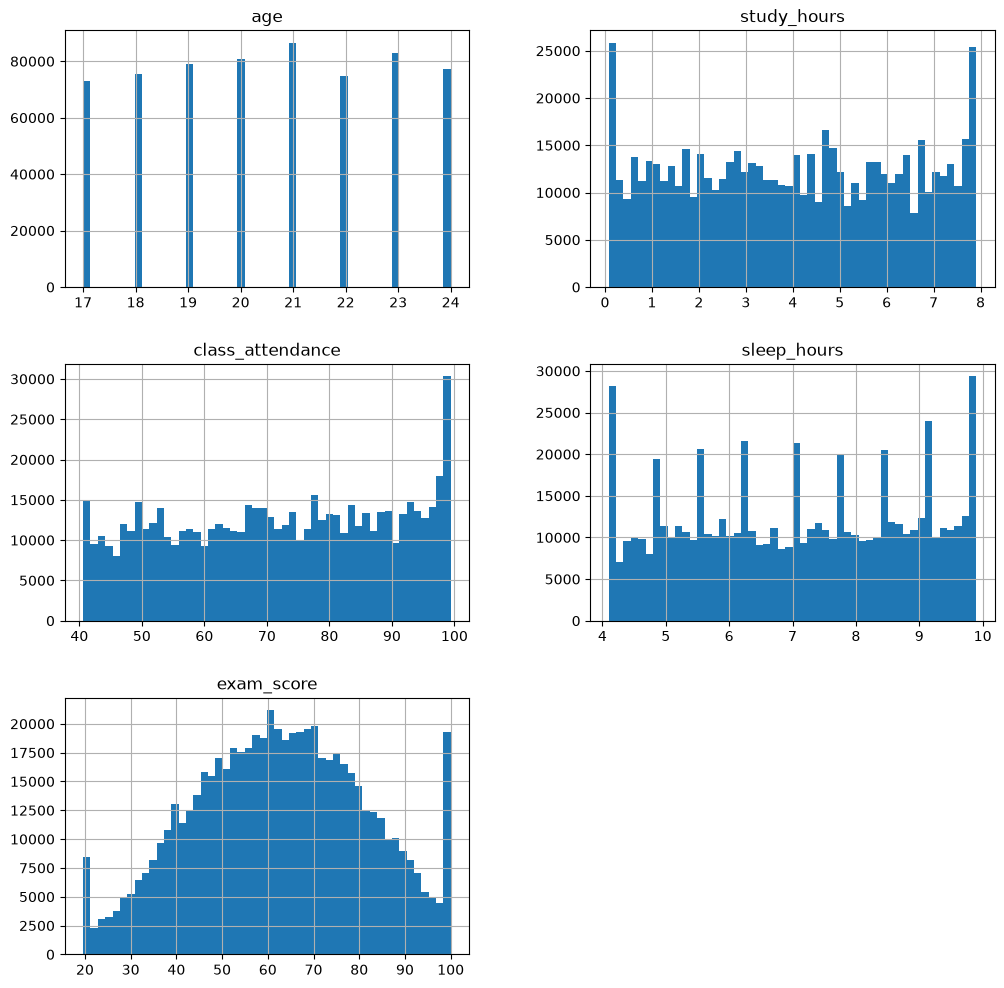

In [17]:
%matplotlib inline
score_data_num = score_data.select_dtypes(include='number').drop(columns=['id'])
score_data_num.hist(bins=50, figsize=(12, 12));

## Observation
- There are an unsually large number of datatpoints clustering at the end, suggesting that the data was capped at both ends
- At this point, I can either figure out if the capped information is important, and try to retrieve the information if possible. However, since no further information could be obtained, I will leave the class as is, and note that the predictions might not be stable beyond the capped values.

In [11]:
# study hours
print("first 5 value counts\n", end='')
print(f"""
{utils.helper.check_capping(score_data['study_hours'])}
{utils.helper.check_capping(score_data['class_attendance'])}
{utils.helper.check_capping(score_data['sleep_hours'])}
{utils.helper.check_capping(score_data['exam_score'])}
""")

first 5 value counts

   study_hours  count
0         0.08  14460
1         0.09    621
2         0.10    590
3         0.11    689
4         0.12    733
   class_attendance  count
0             40.60   6985
1             40.66      1
2             40.70    529
3             40.80    690
4             40.90    609
   sleep_hours  count
0         4.10  17928
1         4.15      1
2         4.20  10282
3         4.30   7095
4         4.40   9552
   exam_score  count
0      19.599   6336
1      19.600    161
2      19.700    110
3      19.800    180
4      19.900    111



In [12]:
print("first 5 value counts\n", end='')
print(f"""
{utils.helper.check_capping(score_data['study_hours'], display_head=False)}
{utils.helper.check_capping(score_data['class_attendance'], display_head=False)}
{utils.helper.check_capping(score_data['sleep_hours'], display_head=False)}
{utils.helper.check_capping(score_data['exam_score'], display_head=False)}
""")

first 5 value counts

   study_hours  count
0         7.87    819
1         7.88    750
2         7.89    629
3         7.90   1019
4         7.91  12840
   class_attendance  count
0              99.0   2068
1              99.1   1241
2              99.2   1483
3              99.3   1022
4              99.4  15264
   sleep_hours  count
0          9.5  10890
1          9.6  11354
2          9.7  12583
3          9.8  10550
4          9.9  18807
   exam_score  count
0        99.6    198
1        99.7    162
2        99.8    228
3        99.9    108
4       100.0  15458



In [13]:
# check the correlation between numerical values
corr_matrix = score_data_num.corr()

## Observation
- Study hours has pretty high correlation to exam score, which is reasonable because the more hours a student puts in, he/she will be likely to get a higher mark
- Class attendace also has a fairly high correlation to exam score
## Todo
- Draw a the scatter plots to inspect the relationship further 

In [14]:
corr_matrix['exam_score'].sort_values(ascending=False)

exam_score          1.000000
study_hours         0.762267
class_attendance    0.360954
sleep_hours         0.167410
age                 0.010472
Name: exam_score, dtype: float64

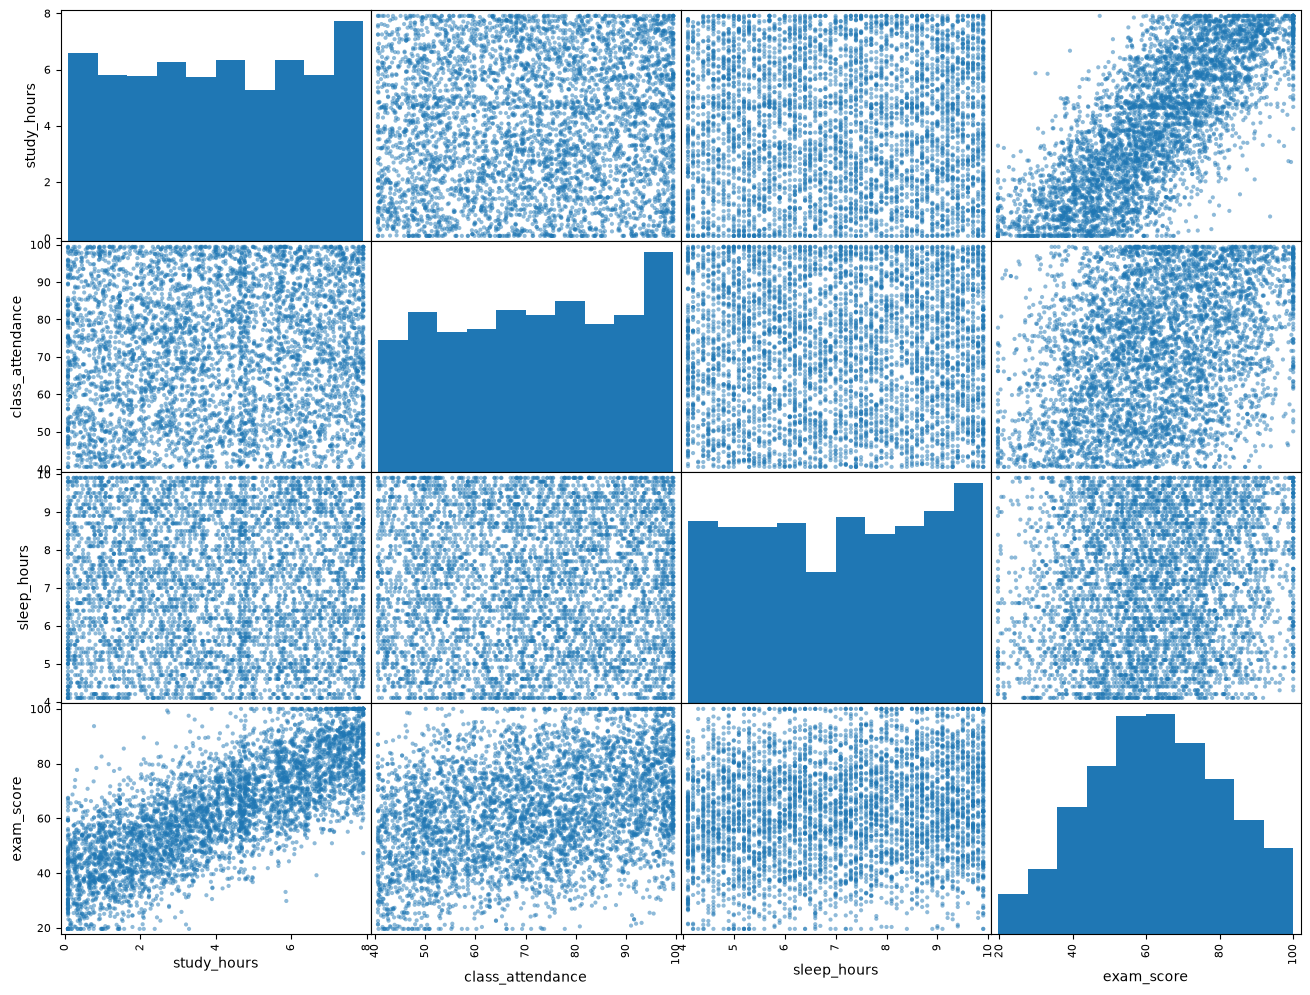

In [15]:
# since the dataset is to large, we just draw a sample here
score_data_sample = score_data.sample(n=5000, random_state=42)
scatter_matrix(score_data_sample.select_dtypes(include='number').drop(columns=['id', 'age']), figsize=(16, 12));

## Observation
- Nothing new was found. The scatter plot between exam_score and study hours show a strong linear correlation
- Other scatter plots don't show any clear
## Todo
- Inspect the categorical columns

In [16]:
# get categorical columns
cat_columns = score_data.select_dtypes(include="str").columns
# categorical audit
for col in cat_columns:
    print(f"\n --- {col} ---")
    print("n_unique: ", score_data[col].nunique())
    print("missing: ", score_data[col].isna().sum())
    print(score_data[col].value_counts(dropna=False).head(20))


 --- gender ---
n_unique:  3
missing:  0
gender
other     211097
male      210593
female    208310
Name: count, dtype: int64

 --- course ---
n_unique:  7
missing:  0
course
b.tech     131236
b.sc       111554
b.com      110932
bca         88721
bba         75644
ba          61989
diploma     49924
Name: count, dtype: int64

 --- internet_access ---
n_unique:  2
missing:  0
internet_access
yes    579423
no      50577
Name: count, dtype: int64

 --- sleep_quality ---
n_unique:  3
missing:  0
sleep_quality
poor       213675
good       213089
average    203236
Name: count, dtype: int64

 --- study_method ---
n_unique:  5
missing:  0
study_method
coaching         131697
self-study       131131
mixed            123086
group study      123009
online videos    121077
Name: count, dtype: int64

 --- facility_rating ---
n_unique:  3
missing:  0
facility_rating
medium    214082
low       212378
high      203540
Name: count, dtype: int64

 --- exam_difficulty ---
n_unique:  3
missing:  0
exam_di

## Observation
- There are no missing values in any columns
- There are no inconsistencies in the categories (e.g. group-study versus group study)
- The distribution among categories doesn't seem to have any strange pattern
## To do
- Create a preprocessing pipeline
- Fit a base line model (linear regression)

## Brain storm area
- Does the ratio between sleep hours and study hours contribute a lot to the prediction of score?
  - This may reveal some interesting insights such as what will the score be if the student spend a lot of time student but very little time sleeping (i.e. large study hours / sleep hours ratio)

## Observation
- The new column seems to have a relatively strong postive correlation with the target.
- We should add the new column to the training to see if it's performing better.

In [35]:
score_data['study_sleep_ratio'] = score_data['study_hours'] / score_data['sleep_hours']
ssr_score_corr = score_data['study_sleep_ratio'].corr(score_data['exam_score'])